<a href="https://colab.research.google.com/github/JACKARPANJACK/AI-Lab-6th-sem/blob/main/Simulated_Annealing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Best solution: 2.0793066339600887
Best value: 3.9937104578099207


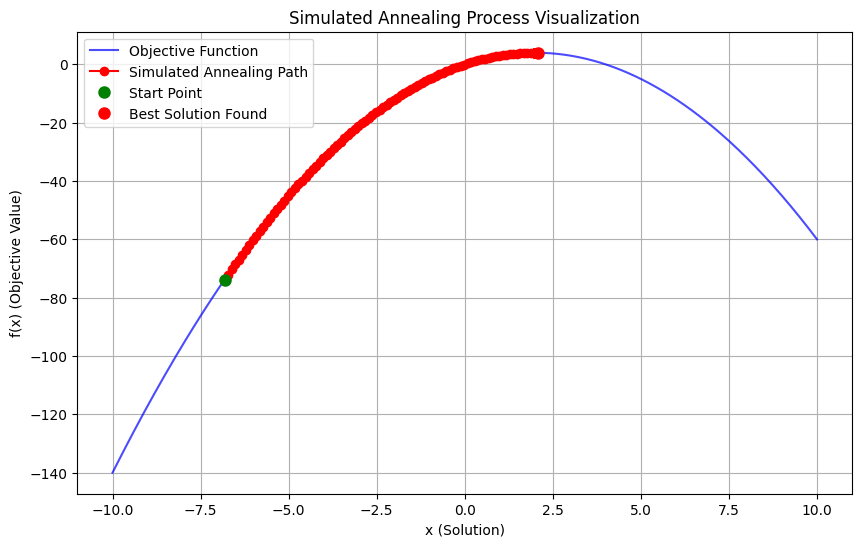

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

def objective_function(x):
    # Example objective function: f(x) = -x**2 + 4*x
    return -x**2 + 4*x

def Simulated_Annealing():
    # Initialize a random solution
    current_solution = random.uniform(-10, 10)
    current_value = objective_function(current_solution)

    step_size = 0.1
    max_iterations = 1000
    temperature = 1000
    cooling_rate = 0.995

    # Store the path for visualization
    solution_history = [current_solution]
    value_history = [current_value]

    for _ in range(max_iterations):
        # Generate neighbors
        neighbors = [current_solution + step_size, current_solution - step_size]

        # Evaluate neighbors
        next_solution_candidate = max(neighbors, key=objective_function)
        next_value_candidate = objective_function(next_solution_candidate)

        # Check if the neighbor is better
        if next_value_candidate > current_value:
            current_solution = next_solution_candidate
            current_value = next_value_candidate
            solution_history.append(current_solution)
            value_history.append(current_value)
        else:
            # Accept the neighbor with a certain probability
            if random.random() < np.exp((next_value_candidate - current_value) / temperature):
                current_solution = next_solution_candidate
                current_value = next_value_candidate
                solution_history.append(current_solution)
                value_history.append(current_value)

        # Cool down the temperature
        temperature *= cooling_rate

    return current_solution, current_value, solution_history, value_history

# Example usage
best_solution, best_value, solution_history, value_history = Simulated_Annealing()
print(f"Best solution: {best_solution}")
print(f"Best value: {best_value}")

# Plotting the process
plt.figure(figsize=(10, 6))

# Plot the objective function
x_vals = np.linspace(-10, 10, 400)
y_vals = objective_function(x_vals)
plt.plot(x_vals, y_vals, label='Objective Function', color='blue', alpha=0.7)

# Plot the simulated annealing path
plt.plot(solution_history, value_history, 'ro-', label='Simulated Annealing Path')
# Mark the starting point and the best solution found
plt.plot(solution_history[0], value_history[0], 'go', markersize=8, label='Start Point')
plt.plot(best_solution, best_value, 'ro', markersize=8, label='Best Solution Found')

plt.title('Simulated Annealing Process Visualization')
plt.xlabel('x (Solution)')
plt.ylabel('f(x) (Objective Value)')
plt.grid(True)
plt.legend()
plt.show()